# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/bank_fin.csv', sep = ';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [3]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [4]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [5]:
df["new_balance"] = df["balance"].apply(lambda x: str(x)[:-2] if pd.notna(x) else x)
df["new_balance"] = (df["new_balance"]
                     .str.replace(',', '.', regex=False)
                     .str.replace(r'\s+', '', regex=True)
                     .str.strip() 
)
df["new_balance"] = df["new_balance"].astype(float)
df["new_balance"].mean()

np.float64(1529.1290293615875)

### Задание 4

In [6]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
# 1. Вычисляем медиану (устойчива к выбросам)
median_value = df["new_balance"].median()
print(median_value)
# 2. Заменяем пропуски на медиану
df["new_balance"] = df["new_balance"].fillna(median_value)

df["new_balance"].mean()

550.0


np.float64(1526.9360329690019)

In [7]:
df['balance'] = df["new_balance"]
df = df.drop("new_balance", axis = 1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Задание 5

In [8]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
mode_job = df[df['job'] != '']['job'].mode()[0]  # если пропуск — пустая строка
mode_education = df[df['education'] != '']['education'].mode()[0]

df['job'] = df['job'].replace('unknown', mode_job)
df['education'] = df['education'].replace('unknown', mode_education)

In [9]:
df['job'].value_counts()
df['education'].value_counts()

education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64

In [10]:
most_common_job = df['job'].mode()[0]
most_common_education = df['education'].mode()[0]
print(f"Самая популярная работа: {most_common_job}")
print(f"Самое популярное образование: {most_common_education}")

Самая популярная работа: management
Самое популярное образование: secondary


In [11]:
grouped = df.groupby(['job', 'education'])['balance'].mean().reset_index()
result = grouped[
    (grouped['job'] == most_common_job) & 
    (grouped['education'] == most_common_education)
]

In [12]:
mean_balance_rounded = round(result['balance'].values[0], 3)
print(f"Средний баланс для клиентов с самой популярной работой и образованием: {mean_balance_rounded}")

Средний баланс для клиентов с самой популярной работой и образованием: 1598.883


### Задание 6

In [13]:
import numpy as np

# Вычисляем границы
data = df['balance'].values
Q1, Q3 = np.percentile(data, [25, 75])
IQR = Q3 - Q1
lower_bound = int(np.round(Q1 - 1.5 * IQR))
upper_bound = int(np.round(Q3 + 1.5 * IQR))

print(f"Границы выбросов: [{lower_bound}, {upper_bound}]")
# Находим индексы выбросов

mask = (df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)
df_filtered = df[mask].copy()
print(f"Осталось строк: {df_filtered.shape[0]}")

Границы выбросов: [-2241, 4063]
Осталось строк: 10105


In [14]:
df_filtered = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)].copy()

print("Осталось строк:", df_filtered.shape[0])  # 10105

df = df_filtered.reset_index(drop=True)

mask = (df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)
df_filtered = df[mask].copy()
print("Осталось строк:", df_filtered.shape[0])
df = df_filtered.reset_index(drop=True)

Осталось строк: 10105
Осталось строк: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

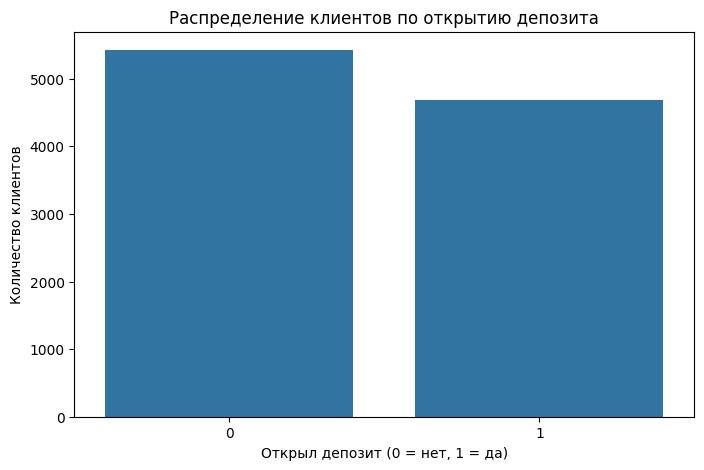

deposit
0    5424
1    4681
Name: count, dtype: int64

In [15]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# ваш код
df['deposit'] = df['deposit'].apply(lambda x: 1 if x == 'yes' else 0)
df['deposit'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='deposit')
plt.title('Распределение клиентов по открытию депозита')
plt.xlabel('Открыл депозит (0 = нет, 1 = да)')
plt.ylabel('Количество клиентов')
plt.show()
df['deposit'].value_counts()

### Задания 2 и 3

In [16]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
df['age'].describe()
df['duration'].describe()

count    10105.000000
mean       368.742603
std        346.651524
min          2.000000
25%        137.000000
50%        252.000000
75%        490.000000
max       3881.000000
Name: duration, dtype: float64

### Задания 4 и 5

In [17]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome
count,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4
top,management,married,secondary,no,no,no,cellular,may,unknown
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570


### Задание 6

Смотрим на данные poutcome:
poutcome
unknown    7570
failure    1109
success     945
other       481
Name: count, dtype: int64

Доля 'yes' для каждого статуса:
failure: 0.0% успеха (1109 клиентов)
success: 0.0% успеха (945 клиентов)
unknown: 0.0% успеха (7570 клиентов)
other: 0.0% успеха (481 клиентов)


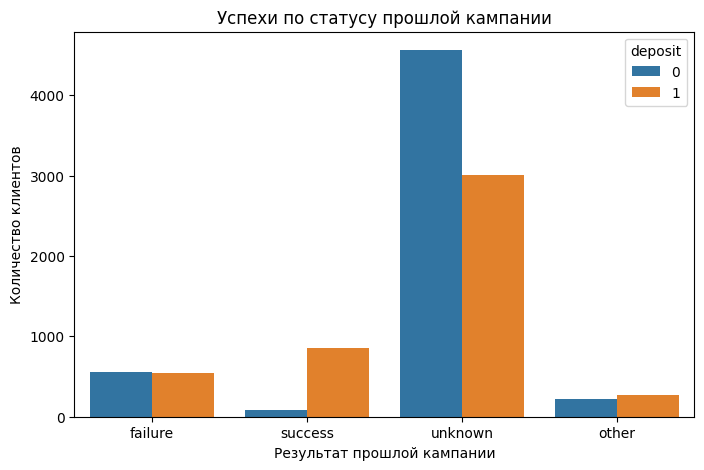

In [18]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код
if 'poutcome' in df.columns:
	poutcome_pivot = df.groupby('poutcome')['deposit'].value_counts(normalize=True).unstack().fillna(0)
   
   
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Простая проверка
print("Смотрим на данные poutcome:")
print(df['poutcome'].value_counts())
print("\nДоля 'yes' для каждого статуса:")

# 2. Простой расчет процента успеха
for status in ['failure', 'success', 'unknown', 'other']:
    group = df[df['poutcome'] == status]
    if len(group) > 0:
        success_rate = (group['deposit'] == 'yes').mean() * 100
        print(f"{status}: {success_rate:.1f}% успеха ({len(group)} клиентов)")

# 3. Простой график
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='poutcome', hue='deposit', 
              order=['failure', 'success', 'unknown', 'other'])
plt.title('Успехи по статусу прошлой кампании')
plt.xlabel('Результат прошлой кампании')
plt.ylabel('Количество клиентов')
plt.show()

### Задание 7

Месяцы в данных: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Процент неудач по месяцам:
month
may    67.863966
jan    60.815047
jul    58.956276
nov    58.461538
aug    55.956679
jun    54.891304
feb    45.557123
apr    38.192771
oct    18.507463
sep    16.546763
mar    10.126582
dec     9.677419
Name: deposit, dtype: float64

Самый высокий процент неудач: 67.9% в месяце 'may'


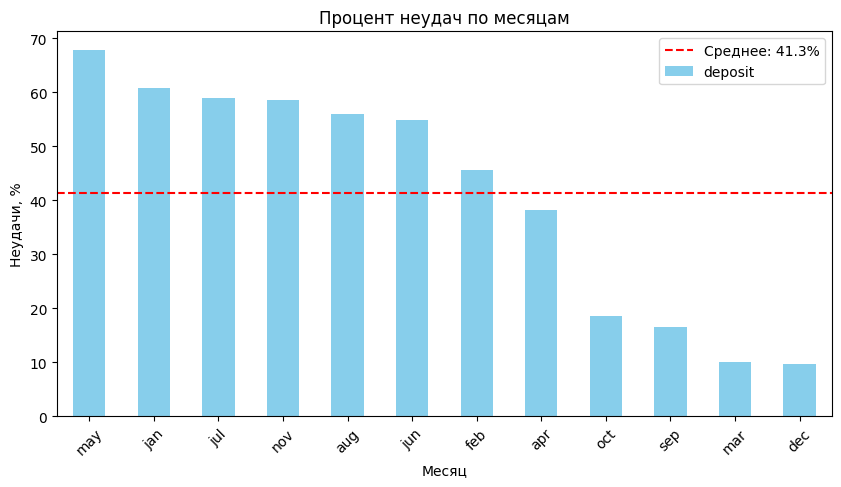

In [19]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
# Проверяем месяцы
print("Месяцы в данных:", sorted(df['month'].unique()))

# Считаем процент неудач (deposit=0)
result = df.groupby('month')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)

print("\nПроцент неудач по месяцам:")
print(result)

# Самый плохой месяц
worst_month = result.index[0]
worst_rate = result.iloc[0]
print(f"\nСамый высокий процент неудач: {worst_rate:.1f}% в месяце '{worst_month}'")

# Визуализация
plt.figure(figsize=(10, 5))
result.plot(kind='bar', color='skyblue')
plt.title('Процент неудач по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Неудачи, %')
plt.axhline(y=result.mean(), color='red', linestyle='--', label=f'Среднее: {result.mean():.1f}%')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Задание 8

In [20]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, 
                         labels=age_labels, 
                         right=False,  # интервал [левая, правая)
                         include_lowest=True)
df['age_group_deposit'] = df.groupby('age_group')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
result = df.groupby('month')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
print("Распределение по возрастным группам:")
print(result.value_counts().sort_index())

Распределение по возрастным группам:
deposit
9.677419     1
10.126582    1
16.546763    1
18.507463    1
38.192771    1
45.557123    1
54.891304    1
55.956679    1
58.461538    1
58.956276    1
60.815047    1
67.863966    1
Name: count, dtype: int64


Анализ возрастных групп:

Процент открытия депозита по возрастным группам:
  60+: 76.0% успеха
  <30: 59.2% успеха
  30-40: 43.3% успеха
  50-60: 40.5% успеха
  40-50: 39.4% успеха

Группы, где успехов БОЛЬШЕ, чем неудач:
  ✓ 60+: 76.0% успеха (преобладают успехи)
  ✓ <30: 59.2% успеха (преобладают успехи)
  ✗ 30-40: 43.3% успеха (преобладают отказы)
  ✗ 50-60: 40.5% успеха (преобладают отказы)
  ✗ 40-50: 39.4% успеха (преобладают отказы)


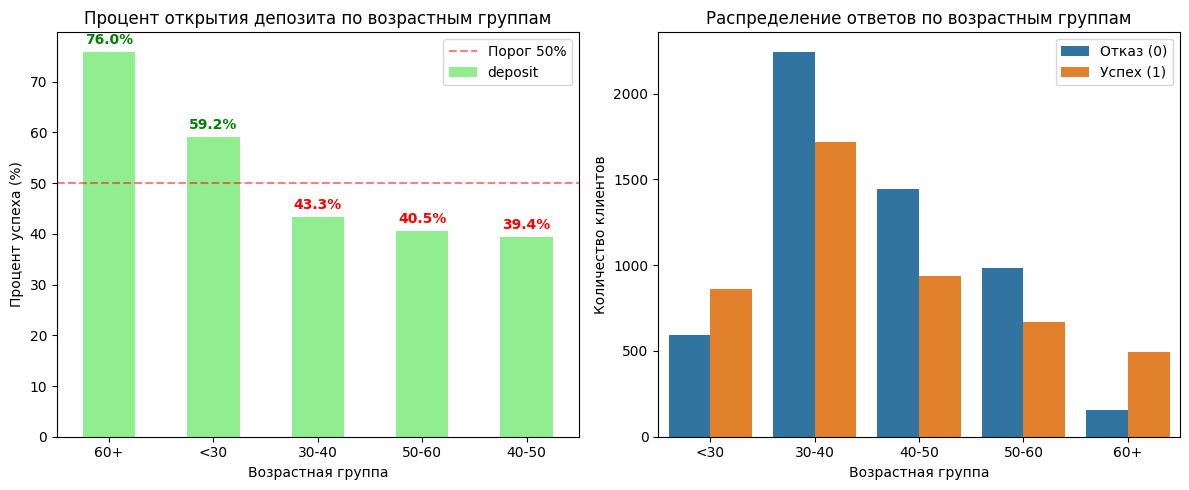

In [42]:
# 1. Создаем возрастные группы
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, 
                         labels=age_labels, 
                         right=False)

# 2. Анализируем склонность к открытию депозита
print("Анализ возрастных групп:\n")

# Считаем процент УСПЕХА (открыли депозит) для каждой группы
if df['deposit'].dtype == 'object':  # если 'yes'/'no'
    success_rate = df.groupby('age_group')['deposit'].apply(
        lambda x: (x == 'yes').mean() * 100
    )
else:  # если 0/1
    success_rate = df.groupby('age_group')['deposit'].apply(
        lambda x: x.mean() * 100
    )

# Сортируем по проценту успеха
success_rate = success_rate.sort_values(ascending=False)

print("Процент открытия депозита по возрастным группам:")
for age_group, rate in success_rate.items():
    print(f"  {age_group}: {rate:.1f}% успеха")

# 3. Определяем группы, где больше успехов, чем неудач
print("\nГруппы, где успехов БОЛЬШЕ, чем неудач:")
for age_group, rate in success_rate.items():
    if rate > 50:  # если успехов больше 50%
        print(f"  ✓ {age_group}: {rate:.1f}% успеха (преобладают успехи)")
    else:
        print(f"  ✗ {age_group}: {rate:.1f}% успеха (преобладают отказы)")

# 4. Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# График 1: Процент успеха
plt.subplot(1, 2, 1)
success_rate.plot(kind='bar', color='lightgreen')
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Порог 50%')
plt.title('Процент открытия депозита по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Процент успеха (%)')
plt.xticks(rotation=0)
plt.legend()

# Добавляем значения на столбцы
for i, v in enumerate(success_rate):
    color = 'green' if v > 50 else 'red'
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', color=color, fontweight='bold')

# График 2: Распределение ответов
plt.subplot(1, 2, 2)
if df['deposit'].dtype == 'object':
    df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0})
    hue_col = 'deposit_binary'
else:
    hue_col = 'deposit'

sns.countplot(data=df, x='age_group', hue=hue_col, order=age_labels)
plt.title('Распределение ответов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество клиентов')
plt.legend(['Отказ (0)', 'Успех (1)'])

plt.tight_layout()
plt.show()



### Задания 9 и 10

In [22]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса

In [23]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования

In [24]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости

### Задание 11

In [25]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)

## Часть 3: преобразование данных

### Задание 1

In [26]:
# преобразуйте уровни образования

### Задания 2 и 3

In [27]:
# преобразуйте бинарные переменные в представление из нулей и единиц

### Задание 4

In [28]:
# создайте дамми-переменные

### Задания 5 и 6

In [29]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности

### Задания 7 и 8

In [30]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [31]:
# рассчитайте необходимые показатели

### Задание 9

In [32]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков

### Задание 10

In [33]:
# нормализуйте данные с помощью minmaxsxaler

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [34]:
# обучите логистическую регрессию и рассчитайте метрики качества

### Задания 2,3,4

In [35]:
# обучите решающие деревья, настройте максимальную глубину

### Задание 5

In [36]:
# подберите оптимальные параметры с помощью gridsearch

# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [37]:
# обучите на ваших данных случайный лес

### Задания 2 и 3

In [38]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом

### Задание 4

In [39]:
# объедините уже известные вам алгоритмы с помощью стекинга 

### Задание 5

In [40]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

### Задания 6,7,8

In [41]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna